In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
 
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
from lifelines import CoxPHFitter
from sklearn.preprocessing import PowerTransformer

In [3]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [4]:
# Need to choose patient_id from OUS_D1 in response_OUS
data = list(OUS_D1['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 
response_OUS.head(10)

# Merge OUS_D1 with response_OUS
clinical_train = pd.merge(OUS_D1, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS', 'LRC', 'event_LRC'])]
clinical_train

,patient_id,OS,event_OS,DFS,event_DFS,LRC,event_LRC
2,5,114.312329,0,32.909589,0,32.909589,0
5,11,111.846575,0,27.715068,0,27.715068,0
6,12,49.479452,1,43.101370,1,49.479452,0
9,15,17.589041,1,17.589041,1,17.589041,0
10,16,66.739726,1,47.473973,1,47.473973,0
14,23,21.106849,1,10.126027,1,10.126027,1
15,24,87.978082,1,87.978082,1,87.978082,0
17,26,62.005479,1,53.983562,1,62.005479,0
18,27,105.073973,0,98.005479,0,98.005479,0
21,31,20.613699,1,3.419178,1,3.419178,1


,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,5,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,11,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,12,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,15,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,16,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,249,60.435616,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.290139,3.650,26.280140,42.805479,0
135,250,68.794521,0,0,1,0,0,1,1.0,0,0.000000,1.0,7.172883,18.967,101.754834,42.739726,0
136,252,57.498630,0,0,1,0,0,1,1.0,1,39.498630,0.0,13.873187,6.370,66.273201,42.312329,0
137,253,65.684932,0,0,1,0,0,1,1.0,1,71.527397,1.0,7.507419,12.443,71.832443,42.246575,0


In [5]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [6]:
# Check null values in D1
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [7]:
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [8]:
# need to choose patient_id from OUS_D1 and OUS_OS_target in response_MAASTRO
data = list(MAASTRO_D1['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [9]:
# Merge MAASTRO_D1 with response_ous
clinical_test = pd.merge(MAASTRO_D1, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'DFS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event
0,1,55,0,0,1,0,0,1,1,1,0,0,15.438583,22.841,263.611623,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,20,1,8.829353,5.660,36.980700,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,6,1,13.476123,7.791,74.636342,44.43,1.0
3,4,61,1,0,0,0,1,1,0,1,45,1,8.632732,7.908,46.791979,37.20,1.0
4,6,70,0,0,1,0,0,1,1,1,59,0,9.783954,15.237,107.637514,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,55,1,31.338410,6.110,144.490782,19.00,1.0
95,111,63,0,0,0,0,1,0,0,1,174,1,13.041604,7.182,69.214868,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,0,1,8.944517,16.483,102.594274,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,0,0,14.184236,9.981,103.229492,58.93,0.0


In [10]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [11]:
# Check if some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,OS_event


In [12]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS'])]

# y 
y = clinical_train.loc[:, ['OS', 'event_OS']]

In [13]:
# Change the form of MAASTRO 
# X
clinical_test.rename(columns = {'OS_event' : 'event_OS'}, inplace = True)
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'event_OS'])]

# y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['OS', 'event_OS']]

# y_MAASTRO into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_OS'], y_MAASTRO['OS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

# Check the shape of clincial_test
clinical_test.shape

(99, 16)

In [14]:
clinical_train.head(10)

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,uicc8_III-IV,SUVpeak,MTV,TLG,OS,event_OS
0,54.238356,1,0,1,0,0,1,0.0,0,0.000000,0.0,14.473272,7.934,86.228420,114.312329,0
1,54.539726,0,0,0,0,1,0,0.0,1,27.404795,0.0,5.044678,1.656,7.040100,111.846575,0
2,59.019178,0,1,0,0,0,1,0.0,1,41.019178,1.0,7.839043,14.502,83.569669,49.479452,1
3,70.726027,0,0,0,0,1,0,0.0,1,37.500000,0.0,2.880631,2.440,5.567091,17.589041,1
4,67.865753,0,0,0,0,1,0,0.0,1,53.000000,0.0,5.402006,3.668,16.150550,66.739726,1
5,57.772603,1,0,0,0,1,1,0.0,0,59.658904,1.0,5.298506,2.846,10.424669,21.106849,1
6,55.791781,0,0,0,0,1,1,0.0,0,56.687671,1.0,8.340148,4.786,31.461777,87.978082,1
7,72.389041,0,0,1,0,0,1,1.0,0,0.000000,0.0,9.301212,7.852,55.919707,62.005479,1
8,53.378082,1,0,1,0,0,1,1.0,0,0.000000,0.0,19.134939,5.898,92.534072,105.073973,0
9,59.076712,0,0,0,1,0,0,0.0,1,41.076712,1.0,17.184191,25.172,317.330329,20.613699,1


# Feature Selection

In [15]:
# Define the columns to be excluded from standardization
excluded_columns = ['female', 
                    'cavum_oris',
                    'oropharynx',
                    'hypopharynx',
                    'larynx',
                    'histgrade_high',
                    'hpv_related',
                    'charlson',
                    'uicc8_III-IV'
                   ]

y_event_os = y['event_OS']

final_sum_results = []  # Store sum results across all iterations

for random_state in range(10): 
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    sum_results = []  # Store sum results for each fold
    
    for train_index, test_index in skf.split(X, y_event_os):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Standardize the included columns
        pt = PowerTransformer(method="yeo-johnson")
        X_train_std = pt.fit_transform(X_train)
        X_test_std = pt.transform(X_test)

        # Change it to a dataframe
        X_train_std = pd.DataFrame(X_train_std, columns=X_train.columns, index=X_train.index)
        X_test_std = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)
        
        final_train_df = pd.concat([X_train_std, y_train], axis=1)
        final_test_df = pd.concat([X_test_std, y_test], axis=1)

        # Fit Cox proportional hazards regression model
        coxph = CoxPHFitter(penalizer=0.0001)
        coxph.fit(final_train_df, duration_col='OS', event_col='event_OS')

        # Get coefficients and associated feature names
        coefficients = coxph.summary['coef']
        feature_names = coxph.summary.index

        # Create a DataFrame to store coefficients and feature names
        coefficients_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

        # Take absolute values of coefficients
        coefficients_df['Abs_Coefficient'] = coefficients_df['Coefficient'].abs()

        # Sort coefficients by absolute value to identify important features
        sorted_coefficients_df = coefficients_df.sort_values(by='Abs_Coefficient', ascending=False)
        
        # Sum absolute coefficients for each feature
        sum_abs_coefficient = sorted_coefficients_df.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
        
        # Append to sum_results for this fold
        sum_results.append(sum_abs_coefficient)

    # Concatenate sum_results for all folds
    fold_sum_results = pd.concat(sum_results)
    
    # Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all folds
    final_sum_fold = fold_sum_results.groupby('Feature')['Abs_Coefficient'].sum().reset_index()
    
    # Append to final_sum_results for all random states
    final_sum_results.append(final_sum_fold)

# Concatenate the DataFrames for all random states
final_result = pd.concat(final_sum_results)

# Group by 'Feature' and calculate the sum of 'Abs_Coefficient' across all iterations and folds
final_sum = final_result.groupby('Feature')['Abs_Coefficient'].sum().reset_index()

# Rename the column for clarity
final_sum.columns = ['Feature', 'Final_Sum_Abs_Coefficient']

final_sum_sorted = final_sum.sort_values(by='Final_Sum_Abs_Coefficient', ascending=False)

# Display the final result
print(final_sum_sorted)

<lifelines.CoxPHFitter: fitted with 92 total observations, 54 right-censored observations>

<lifelines.CoxPHFitter: fitted with 93 total observations, 55 right-censored observations>

<lifelines.CoxPHFitter: fitted with 93 total observations, 55 right-censored observations>

<lifelines.CoxPHFitter: fitted with 92 total observations, 54 right-censored observations>

<lifelines.CoxPHFitter: fitted with 93 total observations, 55 right-censored observations>

...

<lifelines.CoxPHFitter: fitted with 93 total observations, 55 right-censored observations>

<lifelines.CoxPHFitter: fitted with 92 total observations, 54 right-censored observations>

<lifelines.CoxPHFitter: fitted with 93 total observations, 55 right-censored observations>

<lifelines.CoxPHFitter: fitted with 93 total observations, 55 right-censored observations>

           Feature  Final_Sum_Abs_Coefficient
2              TLG                  81.914559
0              MTV                  53.694587
1          SUVpeak                  36.822726
8      hpv_related                  23.918163
13    uicc8_III-IV                  12.599666
12      pack_years                   8.211428
5         charlson                   8.018419
11      oropharynx                   7.049939
9      hypopharynx                   6.790571
3              age                   6.546067
10          larynx                   5.476675
7   histgrade_high                   3.510732
4       cavum_oris                   3.249823
6           female                   3.123430


<Figure size 1000x600 with 0 Axes>

<BarContainer object of 14 artists>

Text(0.5, 0, 'Features')

Text(0, 0.5, 'Sum of Absolute Importance Values')

Text(0.5, 1.0, 'Feature Importance using CoxPH Fitter')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

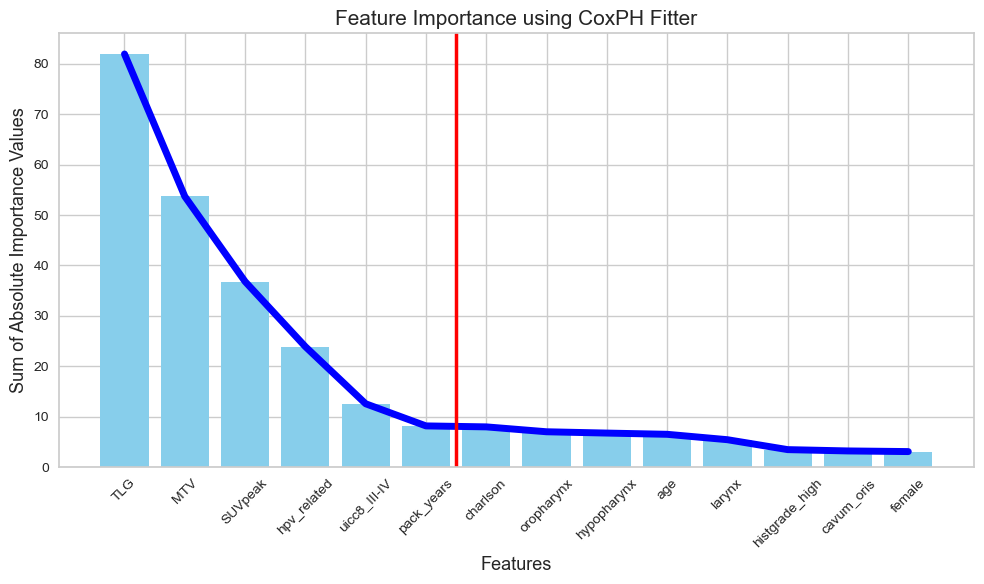

In [16]:
# Plot the bar graph
plt.figure(figsize=(10, 6)) 
plt.bar(final_sum_sorted['Feature'], 
        final_sum_sorted['Final_Sum_Abs_Coefficient'], 
        color='skyblue')
plt.plot(final_sum_sorted['Feature'], 
         final_sum_sorted['Final_Sum_Abs_Coefficient'], 
         color='blue',
        linewidth=5)
plt.xlabel('Features', fontsize=13) 
plt.ylabel('Sum of Absolute Importance Values', fontsize=13) 
plt.title('Feature Importance using CoxPH Fitter', fontsize=15)
plt.xticks(rotation=45) 
plt.axvline(x=5.5, color='red', linestyle='-', linewidth=2.5) 
plt.tight_layout()  
plt.show()

In [17]:
selected_features = final_sum_sorted[0:6]['Feature']
selected_features

2              TLG
0              MTV
1          SUVpeak
8      hpv_related
13    uicc8_III-IV
12      pack_years
Name: Feature, dtype: object

In [18]:
# Selecting features in the DataFrame
X_cfi = X[selected_features]
X_new = X_cfi.copy()

X_MAASTRO_cfi = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_cfi.copy()

In [19]:
X_new.shape

(139, 6)

# Yeo Johnson Transformation

In [20]:
# Transform X_new 
# Set the categorical_columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
X_new_numeric_transformed = pt.fit_transform(X_new_numeric)

# Create DataFrame with transformed numerical data
X_new_numeric_transformed = pd.DataFrame(X_new_numeric_transformed, 
                                         columns=X_new_numeric.columns, 
                                         index=X_new.index)

# Concatenate transformed numerical data with categorical data
X_new_std = pd.concat([X_new_numeric_transformed, X_new_categoric], axis=1)
X_new_std = X_new_std[X_new.columns]

# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the transformation for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = pt.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 
MAASTRO_new = MAASTRO_new[X_new.columns]
MAASTRO_new_std = MAASTRO_new_std[X_new.columns]

In [21]:
X_new

,TLG,MTV,SUVpeak,hpv_related,uicc8_III-IV,pack_years
0,86.228420,7.934,14.473272,0.0,0.0,0.000000
1,7.040100,1.656,5.044678,0.0,0.0,27.404795
2,83.569669,14.502,7.839043,0.0,1.0,41.019178
3,5.567091,2.440,2.880631,0.0,0.0,37.500000
4,16.150550,3.668,5.402006,0.0,0.0,53.000000
...,...,...,...,...,...,...
134,26.280140,3.650,9.290139,1.0,0.0,0.000000
135,101.754834,18.967,7.172883,1.0,1.0,0.000000
136,66.273201,6.370,13.873187,1.0,0.0,39.498630
137,71.832443,12.443,7.507419,1.0,1.0,71.527397


In [22]:
X_new_std

,TLG,MTV,SUVpeak,hpv_related,uicc8_III-IV,pack_years
0,0.343545,0.080033,0.750782,0.0,0.0,-1.533345
1,-1.657833,-1.722060,-1.213660,0.0,0.0,0.397233
2,0.318631,0.735716,-0.474112,0.0,1.0,0.830437
3,-1.835650,-1.291020,-1.992620,0.0,0.0,0.727938
4,-1.003396,-0.816679,-1.106304,0.0,0.0,1.144253
...,...,...,...,...,...,...
134,-0.611074,-0.822461,-0.158214,1.0,0.0,-1.533345
135,0.474941,1.008070,-0.632361,1.0,1.0,-1.533345
136,0.133612,-0.170908,0.658564,1.0,0.0,0.786825
137,0.197985,0.574668,-0.551725,1.0,1.0,1.554125


In [23]:
MAASTRO_new

,TLG,MTV,SUVpeak,hpv_related,uicc8_III-IV,pack_years
0,263.611623,22.841,15.438583,1,0,0
1,36.980700,5.660,8.829353,0,1,20
2,74.636342,7.791,13.476123,0,1,6
3,46.791979,7.908,8.632732,0,1,45
4,107.637514,15.237,9.783954,1,0,59
...,...,...,...,...,...,...
94,144.490782,6.110,31.338410,0,1,55
95,69.214868,7.182,13.041604,0,1,174
96,102.594274,16.483,8.944517,1,1,0
97,103.229492,9.981,14.184236,1,0,0


In [24]:
MAASTRO_new_std

,TLG,MTV,SUVpeak,hpv_related,uicc8_III-IV,pack_years
0,1.218887,1.188930,0.893634,1,0,-1.533345
1,-0.335276,-0.307894,-0.254678,0,1,0.104884
2,0.228548,0.059450,0.595996,0,1,-0.713198
3,-0.145668,0.076321,-0.296877,0,1,0.940197
4,0.519421,0.786849,-0.058378,1,0,1.285347
...,...,...,...,...,...,...
94,0.751363,-0.219083,2.645651,0,1,1.192311
95,0.168333,-0.033134,0.526028,0,1,3.094727
96,0.481447,0.867254,-0.230255,1,1,-1.533345
97,0.486335,0.336049,0.706707,1,0,-1.533345


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [151]:
# Setting the y format for skf below  
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-13 23:55:50,628] A new study created in memory with name: no-name-d3d0998b-1ed5-444d-81f8-590a3c5834c7


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.7272727272727273
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8235294117647058


[I 2024-04-13 23:55:52,470] A new study created in memory with name: no-name-31c9b5a9-f296-4524-90d9-d8db32c56547


Fold 4 C-index: 0.8312236286919831
Fold 5 C-index: 0.6619718309859155
[I 2024-04-13 23:55:52,459] Trial 0 finished with value: 0.7641566626002092 and parameters: {}. Best is trial 0 with value: 0.7641566626002092.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7641566626002092], datetime_start=datetime.datetime(2024, 4, 13, 23, 55, 50, 670514), datetime_complete=datetime.datetime(2024, 4, 13, 23, 55, 52, 458427), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7641566626002092


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.16623488447433168
Fold 2 IBS: 0.19593523221175982
Fold 3 IBS: 0.15515090814625096
Fold 4 IBS: 0.14063535725304396
Fold 5 IBS: 0.24973498311434456
[I 2024-04-13 23:55:54,491] Trial 0 finished with value: 0.18153827303994619 and parameters: {}. Best is trial 0 with value: 0.18153827303994619.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18153827303994619], datetime_start=datetime.datetime(2024, 4, 13, 23, 55, 52, 511118), datetime_complete=datetime.datetime(2024, 4, 13, 23, 55, 54, 491017), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18153827303994619


In [152]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [153]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.764
train_ibs:  0.182


#### Test

In [154]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [155]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.61
IBS score: 0.263


In [156]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [157]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [117]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])


            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-21 14:29:50,098] A new study created in memory with name: no-name-53d27b0f-19fb-45ed-a709-48c48bc80fd5


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-21 14:29:50,240] A new study created in memory with name: no-name-4fbdcd22-5bed-4b6d-a33e-d60f5aa2f1ed


Fold 1 C-index: 0.6885369532428356
Fold 2 C-index: 0.7154742096505824
Fold 3 C-index: 0.6201612903225806
[I 2024-04-21 14:29:50,236] Trial 0 finished with value: 0.6747241510719996 and parameters: {}. Best is trial 0 with value: 0.6747241510719996.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6747241510719996], datetime_start=datetime.datetime(2024, 4, 21, 14, 29, 50, 123885), datetime_complete=datetime.datetime(2024, 4, 21, 14, 29, 50, 236298), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6747241510719996


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2112638563965383
Fold 2 IBS: 0.20804182128829932
Fold 3 IBS: 0.20870986885516205
[I 2024-04-21 14:29:50,378] Trial 0 finished with value: 0.20933851551333324 and parameters: {}. Best is trial 0 with value: 0.20933851551333324.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.20933851551333324], datetime_start=datetime.datetime(2024, 4, 21, 14, 29, 50, 270254), datetime_complete=datetime.datetime(2024, 4, 21, 14, 29, 50, 377970), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.20933851551333324


In [118]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

NameError: name 'train_cindex' is not defined

In [119]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.675
train_ibs:  0.209


#### Test

In [120]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [121]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.496


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.214


In [122]:
# Saving the values to the dictionary 
test_cindex['CoxRidge'] = c_index
test_ibs['CoxRidge'] = ibs

NameError: name 'test_cindex' is not defined

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [25]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            # y_total into array  
            y_total = []
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_total.append((i, j))
                
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_total.append((i, j))
            y_total = np.array(y_total, dtype=[('status', bool), ('time', np.int32)])
            

            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_total["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_total, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-21 15:34:17,565] A new study created in memory with name: no-name-7c38cbba-c759-4fa8-93a5-e31ebb4c3264


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-21 15:34:17,798] A new study created in memory with name: no-name-8aca68a9-d960-4187-80ba-7c336cb36955


Fold 1 C-index: 0.7541478129713424
Fold 2 C-index: 0.8535773710482529
Fold 3 C-index: 0.6951612903225807
[I 2024-04-21 15:34:17,794] Trial 0 finished with value: 0.7676288247807254 and parameters: {}. Best is trial 0 with value: 0.7676288247807254.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.7676288247807254], datetime_start=datetime.datetime(2024, 4, 21, 15, 34, 17, 632189), datetime_complete=datetime.datetime(2024, 4, 21, 15, 34, 17, 794263), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.7676288247807254


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.15909713933174313
Fold 2 IBS: 0.1516317855489626
Fold 3 IBS: 0.2331384856935716
[I 2024-04-21 15:34:18,009] Trial 0 finished with value: 0.18128913685809245 and parameters: {}. Best is trial 0 with value: 0.18128913685809245.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.18128913685809245], datetime_start=datetime.datetime(2024, 4, 21, 15, 34, 17, 828747), datetime_complete=datetime.datetime(2024, 4, 21, 15, 34, 18, 9623), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.18128913685809245


In [26]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

NameError: name 'train_cindex' is not defined

In [ ]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

#### Test

In [27]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [28]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.612


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.233


In [76]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

NameError: name 'test_cindex' is not defined

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [154]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            # y_total into array  
            y_total = []
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_total.append((i, j))
                
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_total.append((i, j))
            y_total = np.array(y_total, dtype=[('status', bool), ('time', np.int32)])
      
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)


            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective
"""
# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)
""" 
# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


'\n# C-index\nstudy_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))\nobjective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)\nstudy_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)\nprint("\n")\nprint("* Best trial for C-index: \n", study_cindex.best_trial)\nprint("\n")\nprint("* Best Score for C-index: \n", study_cindex.best_value)\n'

[I 2024-04-21 14:45:13,571] A new study created in memory with name: no-name-851b1904-a150-4be5-9719-236bcd109be3


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.17081030057065977
Fold 2 IBS: 0.1569118840460072
Fold 3 IBS: 0.2118754468663751
[I 2024-04-21 14:45:13,784] Trial 0 finished with value: 0.17986587716101402 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.17986587716101402.
Fold 1 IBS: 0.17109983123021347
Fold 2 IBS: 0.15679625305411804
Fold 3 IBS: 0.21190663647032926
[I 2024-04-21 14:45:13,975] Trial 1 finished with value: 0.17993424025155358 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.17986587716101402.
Fold 1 IBS: 0.17115085181764048
Fold 2 IBS: 0.15676923303132156
Fold 3 IBS: 0.21186822987737922
[I 2024-04-21 14:45:14,168] Trial 2 finished with value: 0.17992943824211374 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 0 with value: 0.17986587716101402.
Fold 1 IBS: 0.17090791160959154
Fold 2 IBS: 0.15686381600479113
Fold 3 IBS: 0.2118506270900483
[I 2024-04-21 14:45:14,343] Trial 3 finished with value: 0.17987411823481034 and paramete

Fold 3 IBS: 0.21191135164900962
[I 2024-04-21 14:45:18,906] Trial 30 finished with value: 0.17985030255396398 and parameters: {'l1_ratio': 0.8953125756014213}. Best is trial 24 with value: 0.1798487377843572.
Fold 1 IBS: 0.1706699824595768
Fold 2 IBS: 0.15693721768463328
Fold 3 IBS: 0.21194100176476707
[I 2024-04-21 14:45:19,068] Trial 31 finished with value: 0.1798494006363257 and parameters: {'l1_ratio': 0.9230770256194121}. Best is trial 24 with value: 0.1798487377843572.
Fold 1 IBS: 0.17068121595657934
Fold 2 IBS: 0.15694326589387544
Fold 3 IBS: 0.21192134030241783
[I 2024-04-21 14:45:19,227] Trial 32 finished with value: 0.17984860738429087 and parameters: {'l1_ratio': 0.9044860401305335}. Best is trial 32 with value: 0.17984860738429087.
Fold 1 IBS: 0.1706188809350671
Fold 2 IBS: 0.15698036691549522
Fold 3 IBS: 0.21201876641743617
[I 2024-04-21 14:45:19,387] Trial 33 finished with value: 0.17987267142266616 and parameters: {'l1_ratio': 0.9971542374955289}. Best is trial 32 with v

Fold 1 IBS: 0.17070882280010652
Fold 2 IBS: 0.1569550549271383
Fold 3 IBS: 0.21199435056616223
[I 2024-04-21 14:45:24,214] Trial 62 finished with value: 0.17988607609780236 and parameters: {'l1_ratio': 0.8698836267921692}. Best is trial 32 with value: 0.17984860738429087.
Fold 1 IBS: 0.1706677519887474
Fold 2 IBS: 0.15693591665164783
Fold 3 IBS: 0.21194557486579182
[I 2024-04-21 14:45:24,373] Trial 63 finished with value: 0.17984974783539567 and parameters: {'l1_ratio': 0.9275061633386542}. Best is trial 32 with value: 0.17984860738429087.
Fold 1 IBS: 0.17074430692007014
Fold 2 IBS: 0.15692867601738375
Fold 3 IBS: 0.21190980766013914
[I 2024-04-21 14:45:24,535] Trial 64 finished with value: 0.1798609301991977 and parameters: {'l1_ratio': 0.8019132091812748}. Best is trial 32 with value: 0.17984860738429087.
Fold 1 IBS: 0.17068975209084428
Fold 2 IBS: 0.1569439971487733
Fold 3 IBS: 0.21191855662842735
[I 2024-04-21 14:45:24,701] Trial 65 finished with value: 0.17985076862268165 and para

Fold 2 IBS: 0.15694933266619632
Fold 3 IBS: 0.21190080122567778
[I 2024-04-21 14:45:29,301] Trial 92 finished with value: 0.17984973880142505 and parameters: {'l1_ratio': 0.88581408160224}. Best is trial 85 with value: 0.17984850521920237.
Fold 1 IBS: 0.17072512411111654
Fold 2 IBS: 0.15691500847614367
Fold 3 IBS: 0.21195485956744414
[I 2024-04-21 14:45:29,469] Trial 93 finished with value: 0.17986499738490144 and parameters: {'l1_ratio': 0.8398428959385563}. Best is trial 85 with value: 0.17984850521920237.
Fold 1 IBS: 0.1706797764016813
Fold 2 IBS: 0.15694273313956628
Fold 3 IBS: 0.21192302055709913
[I 2024-04-21 14:45:29,637] Trial 94 finished with value: 0.17984851003278224 and parameters: {'l1_ratio': 0.9060468145829407}. Best is trial 85 with value: 0.17984850521920237.
Fold 1 IBS: 0.170735707209905
Fold 2 IBS: 0.15692236827255718
Fold 3 IBS: 0.21193048462274505
[I 2024-04-21 14:45:29,814] Trial 95 finished with value: 0.17986285336840244 and parameters: {'l1_ratio': 0.8189065995

In [150]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

NameError: name 'train_cindex' is not defined

In [151]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.763
train_ibs:  0.181


#### Test

In [152]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [153]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.22692876841884668)

test_cindex : 0.61


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.9044860401305335)

test_ibs:  0.233


In [175]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [156]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective
"""
# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)
""" 
# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

'\n# C-index\nstudy_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))\nobjective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)\nstudy_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)\nprint("\n")\nprint("* Best trial for C-index: \n", study_cindex.best_trial)\nprint("\n")\nprint("* Best Score for C-index: \n", study_cindex.best_value)\n'

[I 2024-04-21 14:45:59,992] A new study created in memory with name: no-name-ef3d987c-5e83-4d53-9d1e-8e195465ca83


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.17490404638887266
Fold 2 IBS: 0.17823026358648916
Fold 3 IBS: 0.2040648789181198
[I 2024-04-21 14:46:01,273] Trial 0 finished with value: 0.18573306296449388 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122}. Best is trial 0 with value: 0.18573306296449388.
Fold 1 IBS: 0.17713595309284944
Fold 2 IBS: 0.1732068511660526
Fold 3 IBS: 0.19657987920914666
[I 2024-04-21 14:46:01,600] Trial 1 finished with value: 0.18230756115601623 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 15, 'max_depth': 4, 'n_estimators': 88, 'oob_score': False, 'max_samples': 0.6709608626961889, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.1614794569265891}. Best is trial 1 with value: 0.18230756115601623.
Fold 1 IBS: 0.2109941702825078
Fold 2 IBS: 0.2077753289472

Fold 1 IBS: 0.2111311793366135
Fold 2 IBS: 0.20805896593220477
Fold 3 IBS: 0.20891353581697733
[I 2024-04-21 14:46:13,922] Trial 18 finished with value: 0.2093678936952652 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 9, 'min_samples_leaf': 10, 'max_depth': 1, 'n_estimators': 169, 'oob_score': True, 'max_samples': 0.8953791319594404, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.4936228322884221}. Best is trial 15 with value: 0.1813318821458246.
Fold 1 IBS: 0.17162720065845483
Fold 2 IBS: 0.17518757615953523
Fold 3 IBS: 0.19984495356739862
[I 2024-04-21 14:46:14,214] Trial 19 finished with value: 0.18221991012846286 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 20, 'n_estimators': 66, 'oob_score': False, 'max_samples': 0.7719763195897029, 'max_features': None, 'min_weight_fraction_leaf': 0.33353903049019823}. Best is trial 15 with value: 0.1813318821458246.
Fold 1 IBS: 0.21129353850040616
Fold 2 IBS: 0.20801850

Fold 1 IBS: 0.1894314440178918
Fold 2 IBS: 0.1877348511961971
Fold 3 IBS: 0.19976111358305232
[I 2024-04-21 14:46:23,758] Trial 36 finished with value: 0.19230913626571375 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 6, 'min_samples_leaf': 16, 'max_depth': 19, 'n_estimators': 79, 'oob_score': False, 'max_samples': 0.8588335615917584, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.4056981277726214}. Best is trial 15 with value: 0.1813318821458246.
Fold 1 IBS: 0.17538890932529133
Fold 2 IBS: 0.1754998120729566
Fold 3 IBS: 0.20388572039940553
[I 2024-04-21 14:46:24,480] Trial 37 finished with value: 0.18492481393255114 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 11, 'min_samples_leaf': 14, 'max_depth': 6, 'n_estimators': 206, 'oob_score': False, 'max_samples': 0.6134779412492984, 'max_features': None, 'min_weight_fraction_leaf': 0.21576287816723366}. Best is trial 15 with value: 0.1813318821458246.
Fold 1 IBS: 0.2113164115980749
Fold 2 IBS: 0.2078155555

Fold 2 IBS: 0.17406544643105967
Fold 3 IBS: 0.20046499035269885
[I 2024-04-21 14:46:31,745] Trial 54 finished with value: 0.18244270701495505 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 9, 'min_samples_leaf': 18, 'max_depth': 17, 'n_estimators': 71, 'oob_score': False, 'max_samples': 0.6853782410802217, 'max_features': None, 'min_weight_fraction_leaf': 0.26055636927341613}. Best is trial 15 with value: 0.1813318821458246.
Fold 1 IBS: 0.1798794487543629
Fold 2 IBS: 0.17890645306911573
Fold 3 IBS: 0.19474588217424763
[I 2024-04-21 14:46:32,244] Trial 55 finished with value: 0.18451059466590877 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 14, 'min_samples_leaf': 14, 'max_depth': 20, 'n_estimators': 130, 'oob_score': False, 'max_samples': 0.8604557082726361, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.34478720714495703}. Best is trial 15 with value: 0.1813318821458246.
Fold 1 IBS: 0.1677341913496913
Fold 2 IBS: 0.17879512535615355
Fold 3 IBS: 0.208834

Fold 1 IBS: 0.17302238648957374
Fold 2 IBS: 0.17592940364132614
Fold 3 IBS: 0.19903399609015837
[I 2024-04-21 14:46:39,986] Trial 72 finished with value: 0.18266192874035272 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 10, 'min_samples_leaf': 19, 'max_depth': 19, 'n_estimators': 50, 'oob_score': False, 'max_samples': 0.8706065682985091, 'max_features': None, 'min_weight_fraction_leaf': 0.32437598738626033}. Best is trial 15 with value: 0.1813318821458246.
Fold 1 IBS: 0.18860179718637396
Fold 2 IBS: 0.19060903757326764
Fold 3 IBS: 0.2064384491147913
[I 2024-04-21 14:46:40,131] Trial 73 finished with value: 0.1952164279581443 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 10, 'min_samples_leaf': 17, 'max_depth': 20, 'n_estimators': 15, 'oob_score': False, 'max_samples': 0.7556541923360565, 'max_features': None, 'min_weight_fraction_leaf': 0.3761216335008184}. Best is trial 15 with value: 0.1813318821458246.
Fold 1 IBS: 0.1729819221422163
Fold 2 IBS: 0.1775707119

Fold 1 IBS: 0.18338468915625777
Fold 2 IBS: 0.1840927880211329
Fold 3 IBS: 0.19589561099392228
[I 2024-04-21 14:46:54,706] Trial 90 finished with value: 0.18779102939043765 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 19, 'min_samples_leaf': 3, 'max_depth': 10, 'n_estimators': 379, 'oob_score': False, 'max_samples': 0.968236957356104, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.42499096509167533}. Best is trial 76 with value: 0.18061666344648974.
Fold 1 IBS: 0.17221727405356566
Fold 2 IBS: 0.17612182499826437
Fold 3 IBS: 0.1981618577994283
[I 2024-04-21 14:46:55,848] Trial 91 finished with value: 0.1821669856170861 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 1, 'max_depth': 13, 'n_estimators': 330, 'oob_score': False, 'max_samples': 0.9999562800334336, 'max_features': None, 'min_weight_fraction_leaf': 0.4158462653473026}. Best is trial 76 with value: 0.18061666344648974.
Fold 1 IBS: 0.17261731938321004
Fold 2 IBS: 0.1749777

In [177]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [178]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.795
train_ibs:  0.18


#### Test

In [160]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [161]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=12, max_features=None, max_leaf_nodes=7,
                     max_samples=0.7163467647263769, min_samples_leaf=5,
                     min_samples_split=15,
                     min_weight_fraction_leaf=0.2192861223398122,
                     n_estimators=360, random_state=123)

test_cindex:  0.607


RandomSurvivalForest(max_depth=12, max_features=None, max_leaf_nodes=15,
                     max_samples=0.8885019769153283, min_samples_leaf=6,
                     min_samples_split=4,
                     min_weight_fraction_leaf=0.3952117393379043,
                     n_estimators=79, random_state=123)

test_ibs:  0.191


In [162]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

NameError: name 'test_cindex' is not defined

### 6. ExtraSurvivalTrees

#### Train

In [182]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-14 00:47:13,402] A new study created in memory with name: no-name-89584219-faa1-4d49-abba-e4523481a90e


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7901785714285714
Fold 3 C-index: 0.8529411764705882
Fold 4 C-index: 0.869198312236287
Fold 5 C-index: 0.6807511737089202
[I 2024-04-14 00:47:16,026] Trial 0 finished with value: 0.7866657948208214 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.7866657948208214.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-14 00:47:23,434] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531}

Fold 4 C-index: 0.8713080168776371
Fold 5 C-index: 0.6572769953051644
[I 2024-04-14 00:48:43,209] Trial 15 finished with value: 0.7790490625333263 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 9, 'min_samples_leaf': 13, 'max_depth': 4, 'n_estimators': 258, 'oob_score': False, 'warm_start': True, 'max_features': 'sqrt', 'max_samples': 0.6880212408103346, 'min_weight_fraction_leaf': 0.07884420972256234}. Best is trial 12 with value: 0.7931041879790215.
Fold 1 C-index: 0.7575757575757576
Fold 2 C-index: 0.7767857142857143
Fold 3 C-index: 0.8088235294117647
Fold 4 C-index: 0.8502109704641351
Fold 5 C-index: 0.6150234741784038
[I 2024-04-14 00:48:46,974] Trial 16 finished with value: 0.761683889183155 and parameters: {'min_samples_split': 20, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.8750346354626457, 'min_weight_fraction_leaf': 0.4093818399278544}. Best is

Fold 1 C-index: 0.7402597402597403
Fold 2 C-index: 0.7857142857142857
Fold 3 C-index: 0.8431372549019608
Fold 4 C-index: 0.8565400843881856
Fold 5 C-index: 0.6455399061032864
[I 2024-04-14 00:49:42,373] Trial 30 finished with value: 0.7742382542734918 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 3, 'min_samples_leaf': 12, 'max_depth': 14, 'n_estimators': 455, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.3838693489032564, 'min_weight_fraction_leaf': 0.10926796937519383}. Best is trial 12 with value: 0.7931041879790215.
Fold 1 C-index: 0.7294372294372294
Fold 2 C-index: 0.7745535714285714
Fold 3 C-index: 0.8431372549019608
Fold 4 C-index: 0.8565400843881856
Fold 5 C-index: 0.6666666666666666
[I 2024-04-14 00:49:43,071] Trial 31 finished with value: 0.7740669613645228 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 5, 'min_samples_leaf': 10, 'max_depth': 11, 'n_estimators': 41, 'oob_score': False, 'warm_start': True, 'max_feat

...

Fold 1 IBS: 0.17428358790749435
Fold 2 IBS: 0.20007188931686504
Fold 3 IBS: 0.17355515571201416
Fold 4 IBS: 0.17439389897666682
Fold 5 IBS: 0.2153698199959979
[I 2024-04-14 01:00:14,132] Trial 30 finished with value: 0.18753487038180766 and parameters: {'min_samples_split': 19, 'max_leaf_nodes': 3, 'min_samples_leaf': 4, 'max_depth': 15, 'n_estimators': 355, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.20530475239315849, 'min_weight_fraction_leaf': 0.020774921326658265}. Best is trial 12 with value: 0.18480685816223635.
Fold 1 IBS: 0.1731391116843521
Fold 2 IBS: 0.20089502517159805
Fold 3 IBS: 0.17087079261668503
Fold 4 IBS: 0.17086830733212208
Fold 5 IBS: 0.22193086407239324
[I 2024-04-14 01:00:25,623] Trial 31 finished with value: 0.1875408201754301 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 8, 'min_samples_leaf': 5, 'max_depth': 13, 'n_estimators': 409, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples':

Fold 1 IBS: 0.16202025056005978
Fold 2 IBS: 0.20639838182421125
Fold 3 IBS: 0.16474732411324386
Fold 4 IBS: 0.15738587531305362
Fold 5 IBS: 0.22593260190277328
[I 2024-04-14 01:03:31,871] Trial 45 finished with value: 0.18329688674266836 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 7, 'min_samples_leaf': 4, 'max_depth': 19, 'n_estimators': 498, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.7461078040634932, 'min_weight_fraction_leaf': 0.004242029379765401}. Best is trial 45 with value: 0.18329688674266836.
Fold 1 IBS: 0.1621099805484316
Fold 2 IBS: 0.20624626679288757
Fold 3 IBS: 0.16517769777652092
Fold 4 IBS: 0.15706349274649611
Fold 5 IBS: 0.22669363605144358
[I 2024-04-14 01:03:44,802] Trial 46 finished with value: 0.18345821478315594 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 9, 'min_samples_leaf': 4, 'max_depth': 19, 'n_estimators': 493, 'oob_score': False, 'warm_start': False, 'max_features': 'log2', 'max_sample

Fold 1 IBS: 0.1703873065862154
Fold 2 IBS: 0.2024718043647015
Fold 3 IBS: 0.17103502849821603
Fold 4 IBS: 0.1694785604100484
Fold 5 IBS: 0.2229769243801152
[I 2024-04-14 01:07:07,963] Trial 60 finished with value: 0.1872699248478593 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 10, 'min_samples_leaf': 4, 'max_depth': 20, 'n_estimators': 452, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.8485797614174531, 'min_weight_fraction_leaf': 0.14032403124297166}. Best is trial 45 with value: 0.18329688674266836.
Fold 1 IBS: 0.16165474205889604
Fold 2 IBS: 0.20826855320131024
Fold 3 IBS: 0.16575656217717316
Fold 4 IBS: 0.15796643897774781
Fold 5 IBS: 0.22698278885325132
[I 2024-04-14 01:07:25,102] Trial 61 finished with value: 0.18412581705367573 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 14, 'min_samples_leaf': 3, 'max_depth': 20, 'n_estimators': 482, 'oob_score': True, 'warm_start': False, 'max_features': 'log2', 'max_samples': 0.9

Fold 1 IBS: 0.1617537803629231
Fold 2 IBS: 0.20725107019348635
Fold 3 IBS: 0.16265007322260938
Fold 4 IBS: 0.15173692794000496
Fold 5 IBS: 0.22832820738369197
[I 2024-04-14 01:09:33,771] Trial 75 finished with value: 0.18234401182054313 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 167, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9530430050532336, 'min_weight_fraction_leaf': 0.04320442388822884}. Best is trial 69 with value: 0.1821557094212927.
Fold 1 IBS: 0.16239899090854987
Fold 2 IBS: 0.20736718262456696
Fold 3 IBS: 0.16350221432053966
Fold 4 IBS: 0.15258800865888567
Fold 5 IBS: 0.22867570631845907
[I 2024-04-14 01:09:39,782] Trial 76 finished with value: 0.18290642056620024 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 19, 'min_samples_leaf': 1, 'max_depth': 16, 'n_estimators': 166, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 

Fold 1 IBS: 0.16057709341835752
Fold 2 IBS: 0.20926771244099288
Fold 3 IBS: 0.16262444920182748
Fold 4 IBS: 0.15279035601075375
Fold 5 IBS: 0.229231660146976
[I 2024-04-14 01:11:11,833] Trial 90 finished with value: 0.18289825424378153 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 20, 'min_samples_leaf': 1, 'max_depth': 14, 'n_estimators': 192, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.9286349054442973, 'min_weight_fraction_leaf': 0.034626641521600374}. Best is trial 69 with value: 0.1821557094212927.
Fold 1 IBS: 0.1579051125413147
Fold 2 IBS: 0.21323462018856765
Fold 3 IBS: 0.1622759264106894
Fold 4 IBS: 0.14806616731988237
Fold 5 IBS: 0.23194409359261503
[I 2024-04-14 01:11:20,260] Trial 91 finished with value: 0.18268518401061382 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 13, 'n_estimators': 225, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.

In [183]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [184]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.849
train_ibs:  0.182


#### Test

In [185]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [186]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=19, max_features=None, max_leaf_nodes=13,
                   max_samples=0.6126020668149661, min_samples_leaf=1,
                   min_samples_split=4,
                   min_weight_fraction_leaf=0.0008624662165404497,
                   n_estimators=196, oob_score=True, random_state=123,
                   warm_start=True)

C-index score: 0.64


ExtraSurvivalTrees(max_depth=19, max_features='auto', max_leaf_nodes=17,
                   max_samples=0.9419038548530119, min_samples_leaf=2,
                   min_weight_fraction_leaf=0.01737067912405657,
                   n_estimators=248, oob_score=True, random_state=123)

IBS: 0.21


In [187]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [ ]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective
""" 
# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)
"""
# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

' \n# C-index\nstudy_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))\nobjective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)\nstudy_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)\nprint("\n")\nprint("* Best trial for C-index: \n", study_cindex.best_trial)\nprint("\n")\nprint("* Best Score for C-index: \n", study_cindex.best_value)\n'

[I 2024-04-21 14:47:53,454] A new study created in memory with name: no-name-d2c6b26e-4938-432c-b974-61343ea2897f


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.21126386475661443
Fold 2 IBS: 0.20804182448413283
Fold 3 IBS: 0.2087098715678942
[I 2024-04-21 14:47:59,597] Trial 0 finished with value: 0.20933852026954716 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.20933852026954716.
Fold 1 IBS: 0.21126386475661443
Fold 2 IBS: 0.2080418244841329
Fold 3 IBS: 0.20870987156789425
[I 2024-04-21 14:48:02,951] Trial 1 finished with value: 0.20933852026954716 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'crite

Fold 3 IBS: 0.20862916956521058
[I 2024-04-21 14:49:44,883] Trial 12 finished with value: 0.20923815496686862 and parameters: {'subsample': 0.873850481285158, 'learning_rate': 0.0012227187192111223, 'dropout_rate': 0.2527776031497929, 'n_estimators': 489, 'criterion': 'squared_error', 'ccp_alpha': 0.058133567268478875, 'min_weight_fraction_leaf': 0.2151989029549357, 'max_features': 'auto', 'min_impurity_decrease': 1.5094636128058346e-06, 'validation_fraction': 0.9945176333416724, 'min_samples_split': 20, 'max_leaf_nodes': 20, 'min_samples_leaf': 15, 'max_depth': 1}. Best is trial 9 with value: 0.20857208848785924.
Fold 1 IBS: 0.21126386475661443
Fold 2 IBS: 0.2080418244841329
Fold 3 IBS: 0.2087098715678942
[I 2024-04-21 14:49:55,172] Trial 13 finished with value: 0.20933852026954716 and parameters: {'subsample': 0.3002626528752279, 'learning_rate': 0.0399128250234414, 'dropout_rate': 0.47793429123548903, 'n_estimators': 394, 'criterion': 'squared_error', 'ccp_alpha': 1.5257399290031846

In [ ]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [ ]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

#### Test

In [ ]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [ ]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

In [193]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis


#### Train

In [23]:
# Setting the y format 
y = clinical_train[['OS', 'event_OS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_OS'], y_train_df['OS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_OS'], y_test_df['OS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]

            # Find intersection of excluded columns with X columns
            excluded_columns = set(excluded_columns).intersection(X.columns)

            # Extract included columns
            included_columns = [col for col in X.columns if col not in excluded_columns]

            # Extract numerical data for included columns
            X_train_included = X_train[included_columns]
            X_test_included = X_test[included_columns]

            # Apply Yeo-Johnson transformation
            pt = PowerTransformer(method='yeo-johnson')
            X_train_included_transformed = pt.fit_transform(X_train_included)
            X_test_included_transformed = pt.transform(X_test_included)

            # Create DataFrame with transformed numerical data
            X_train_included_transformed_df = pd.DataFrame(X_train_included_transformed, columns=included_columns, index=X_train_included.index)
            X_test_included_transformed_df = pd.DataFrame(X_test_included_transformed, columns=included_columns, index=X_test_included.index)

            # Concatenate transformed numerical data with excluded columns
            X_train_std = pd.concat([X_train_included_transformed_df, X_train[list(excluded_columns)]], axis=1)
            X_test_std = pd.concat([X_test_included_transformed_df, X_test[list(excluded_columns)]], axis=1)

            model.fit(X_train_std, y_train)


            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

"""
# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)
""" 
# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


'\n# C-index\nstudy_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))\nobjective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)\nstudy_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)\nprint("\n")\nprint("* Best trial for C-index: \n", study_cindex.best_trial)\nprint("\n")\nprint("* Best hyperparameters for C-index: \n", study_cindex.best_params)\nprint("\n")\nprint("* Best Score for C-index: \n", study_cindex.best_value)\n'

[I 2024-04-21 14:01:09,071] A new study created in memory with name: no-name-d62bacbf-eb65-461f-a98c-02c032083dc6


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.18361100589808596
Fold 2 IBS: 0.1998429339245168
Fold 3 IBS: 0.24284814397770632
[I 2024-04-21 14:01:09,454] Trial 0 finished with value: 0.20876736126676967 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.20876736126676967.
Fold 1 IBS: 0.19783375859199498
Fold 2 IBS: 0.2858398107371403
Fold 3 IBS: 0.2987267203237632
[I 2024-04-21 14:01:11,993] Trial 1 finished with value: 0.2608000965509662 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.20876736126676967.
Fold 1 IBS: 0.1889898011947053
Fold 2 IBS: 0.23987113192187687
Fold 3 IBS: 0.2672233924156122
[I 2024-04-21 14:01:12,500] Trial 2 finished with value: 0.23202810851073144 and parameters: {'subsample': 0.5328387113359249, 'dropout_rate': 0.45290576637473545, 'n_estimat

Fold 1 IBS: 0.17046269275368503
Fold 2 IBS: 0.1831865213241975
Fold 3 IBS: 0.2301741375173253
[I 2024-04-21 14:01:23,567] Trial 23 finished with value: 0.19460778386506927 and parameters: {'subsample': 0.19369753798035044, 'dropout_rate': 0.7930385598318731, 'n_estimators': 146, 'learning_rate': 0.0396495042605266}. Best is trial 19 with value: 0.1922014039875843.
Fold 1 IBS: 0.18209065846742867
Fold 2 IBS: 0.18463849613966923
Fold 3 IBS: 0.21633207820256226
[I 2024-04-21 14:01:23,751] Trial 24 finished with value: 0.19435374426988672 and parameters: {'subsample': 0.3980179643829882, 'dropout_rate': 0.9047292366273245, 'n_estimators': 56, 'learning_rate': 0.06234977614697124}. Best is trial 19 with value: 0.1922014039875843.
Fold 1 IBS: 0.1787807101103101
Fold 2 IBS: 0.18198610103066132
Fold 3 IBS: 0.21240876984221865
[I 2024-04-21 14:01:23,987] Trial 25 finished with value: 0.1910585269943967 and parameters: {'subsample': 0.211474360454084, 'dropout_rate': 0.7565916135854155, 'n_estim

Fold 1 IBS: 0.17582376894671398
Fold 2 IBS: 0.18151270459475957
Fold 3 IBS: 0.22312714279530466
[I 2024-04-21 14:01:34,683] Trial 46 finished with value: 0.1934878721122594 and parameters: {'subsample': 0.28120963500463964, 'dropout_rate': 0.5383724314247292, 'n_estimators': 134, 'learning_rate': 0.030689817448582696}. Best is trial 42 with value: 0.1873456233105474.
Fold 1 IBS: 0.21512803516430054
Fold 2 IBS: 0.20148729711612276
Fold 3 IBS: 0.20512642893928965
[I 2024-04-21 14:01:34,825] Trial 47 finished with value: 0.2072472537399043 and parameters: {'subsample': 0.14437803114081793, 'dropout_rate': 0.682219087408883, 'n_estimators': 22, 'learning_rate': 0.008209618821055878}. Best is trial 42 with value: 0.1873456233105474.
Fold 1 IBS: 0.19798184361323268
Fold 2 IBS: 0.187684994025573
Fold 3 IBS: 0.202944103372864
[I 2024-04-21 14:01:35,095] Trial 48 finished with value: 0.19620364700388992 and parameters: {'subsample': 0.7148901978200634, 'dropout_rate': 0.6022536372318593, 'n_est

Fold 3 IBS: 0.2111776818617501
[I 2024-04-21 14:01:44,222] Trial 69 finished with value: 0.19081983098129052 and parameters: {'subsample': 0.23615561686495834, 'dropout_rate': 0.9212661732616101, 'n_estimators': 102, 'learning_rate': 0.03418184591815593}. Best is trial 42 with value: 0.1873456233105474.
Fold 1 IBS: 0.18734743451387473
Fold 2 IBS: 0.21234272434615314
Fold 3 IBS: 0.25409923880521457
[I 2024-04-21 14:01:44,821] Trial 70 finished with value: 0.2179297992217475 and parameters: {'subsample': 0.8428593601922311, 'dropout_rate': 0.6377675676170155, 'n_estimators': 199, 'learning_rate': 0.0406011867295798}. Best is trial 42 with value: 0.1873456233105474.
Fold 1 IBS: 0.18378585579968207
Fold 2 IBS: 0.17884560382930126
Fold 3 IBS: 0.2017964678370626
[I 2024-04-21 14:01:45,109] Trial 71 finished with value: 0.18814264248868198 and parameters: {'subsample': 0.16601843974374247, 'dropout_rate': 0.7680686867699116, 'n_estimators': 99, 'learning_rate': 0.027990289735957376}. Best is 

Fold 3 IBS: 0.2009004075524065
[I 2024-04-21 14:01:52,379] Trial 92 finished with value: 0.19829704748441887 and parameters: {'subsample': 0.20135706009232318, 'dropout_rate': 0.8212474572462098, 'n_estimators': 33, 'learning_rate': 0.029682916880853397}. Best is trial 88 with value: 0.1872633398047819.
Fold 1 IBS: 0.18312875360096473
Fold 2 IBS: 0.1781124656183031
Fold 3 IBS: 0.2024403157660422
[I 2024-04-21 14:01:52,668] Trial 93 finished with value: 0.18789384499510334 and parameters: {'subsample': 0.15352049992418587, 'dropout_rate': 0.41200689746521035, 'n_estimators': 91, 'learning_rate': 0.03170408546218363}. Best is trial 88 with value: 0.1872633398047819.
Fold 1 IBS: 0.17301480392172136
Fold 2 IBS: 0.17493249586207374
Fold 3 IBS: 0.2189798199153036
[I 2024-04-21 14:01:53,058] Trial 94 finished with value: 0.18897570656636622 and parameters: {'subsample': 0.1766416542607424, 'dropout_rate': 0.4081285024556842, 'n_estimators': 128, 'learning_rate': 0.03707765458450222}. Best is 

In [24]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

NameError: name 'train_cindex' is not defined

In [ ]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

#### Test

In [25]:
# y into array 
lists = [] 
for i, j in zip(y['event_OS'], y['OS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [27]:

# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)
""" 
# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)
""" 
# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

' \n# Set the best model \nbest_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)\n\n# Train the best model for C-index on the whole dataset\nbest_model_cindex.fit(X_new_std, y)\n\n# Evaluate the best model for C-index on MAASTRO dataset\nc_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)\nc_index = np.round(c_index, 3)\nprint("C-index score:", c_index)\n'

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.7082487250340442,
                                              learning_rate=0.029365633415397857,
                                              n_estimators=116,
                                              random_state=123,
                                              subsample=0.16441482194358498)

IBS: 0.249


In [28]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

NameError: name 'c_index' is not defined

## Results

In [200]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
ExtraSurvivalTrees,0.849,1.0
Randomsurvivalforest,0.795,2.0
CoxPH,0.764,3.0
CoxElastic,0.763,4.0
CoxLasso,0.762,5.0
GradientBoosting,0.744,6.0
ComponentwiseGradientBoosting,0.729,7.0
CoxRidge,0.660,8.0


In [201]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
CoxLasso,0.180,2.0
CoxElastic,0.180,2.0
Randomsurvivalforest,0.180,2.0
CoxPH,0.182,4.5
ExtraSurvivalTrees,0.182,4.5
ComponentwiseGradientBoosting,0.188,6.0
GradientBoosting,0.215,7.0
CoxRidge,0.217,8.0


In [202]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
Randomsurvivalforest,0.655,1.0
ExtraSurvivalTrees,0.640,2.0
CoxLasso,0.612,3.0
CoxPH,0.610,4.5
CoxElastic,0.610,4.5
GradientBoosting,0.588,6.0
ComponentwiseGradientBoosting,0.532,7.0
CoxRidge,0.496,8.0


In [203]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
Randomsurvivalforest,0.210,1.5
ExtraSurvivalTrees,0.210,1.5
GradientBoosting,0.219,3.0
CoxRidge,0.221,4.0
ComponentwiseGradientBoosting,0.251,5.0
CoxLasso,0.260,6.5
CoxElastic,0.260,6.5
CoxPH,0.263,8.0


In [204]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d1/os/yeojohnson/cfi/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d1_os_yeojohnson_cfi_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [205]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-14
